# Representative UMAP of BICAN April 2026 freeze data

A demo to show off the new `cellarium.ml.api` module, streamlining interactive work.

Stephen Fleming

2026.09.25

Can run on a laptop, but if using GCS bucket files, much better to run on a google VM due to network bandwidth.

Without localizing files, takes 3 hours to run HVGs on my laptop on my home internet. Takes ~10 mins on a google VM.

If you can download all the h5ad files locally, all of this will be much faster.

## Specify data location

The way this demo works is by pointing at a google bucket with h5ad files.
If you have a list of h5ad files anywhere else, you can simply input the paths as a list for the `h5ad_paths` when instantiating `CellariumData`.

This is a data extract created by Cellarium Nexus, containing 3.86M cells.

In [1]:
h5ad_base_path = "gs://cellarium-nexus-file-system-3293a8/pipeline/data-extracts/bican_202604_fullextract/extract_files"

In [ ]:
# can choose whether to run on CPU or MPS or CUDA

ACCELERATOR = "cuda"  # should be in ["cpu", "mps", "cuda"]
NUM_DATALOADER_WORKERS = 12  # this works well on an n1-standard-16 with 16 vCPUs: adjust based on hardware

## Imports

In [ ]:
import cellarium.ml.api as cml
import scanpy as sc
sc.set_figure_params(fontsize=14, vector_friendly=True)

import matplotlib.pyplot as plt
%matplotlib inline

/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data setup

In [ ]:
# set up datamodule: can take a minute for hundreds of files

cdata = cml.CellariumData(
    h5ad_paths=cml.h5ad_paths_from_google_bucket(h5ad_base_path),
    total_mrna_umis_column="n_counts",
    var_key="gene_name",
    datamodule_num_workers=NUM_DATALOADER_WORKERS,
    accelerator=ACCELERATOR,
)
cdata

Reading n_obs from h5ad files: 100%|██████████| 2/2 [00:00<00:00,  2.19file/s]


CellariumData(shape [3857513, 38094], obsm keys: [], hvg_set=False)

## Highly variable gene selection

In [ ]:
# run highly variable gene selection

hvg_df, hvg_module = cml.pp.highly_variable_genes(
    cdata,
    n_top_genes=4000,
    flavor="seurat",
    accelerator=ACCELERATOR,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


/home/sfleming/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 0:   0%|          | 0/942 [00:00<?, ?it/s] 

/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/torch/multiprocessing/reductions.py:473: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  return torch.sparse_compressed_tensor(


Epoch 0: 100%|██████████| 942/942 [09:35<00:00,  1.64it/s]


In [6]:
# a side-effect of running highly_variable_genes is that cdata.hvg stores the result

cdata.hvg

A1BG           False
A1BG-AS1       False
A1CF           False
A2M             True
A2M-AS1        False
               ...  
TRAJ60         False
FAM90A23       False
IGHVII-44-2    False
PRR23D2        False
TRGJP          False
Name: highly_variable, Length: 38094, dtype: bool

In [7]:
cdata.hvg.sum()

4000

In [8]:
# the result is also in hvg_df

hvg_df

,means,dispersions,mean_bin,dispersions_norm,highly_variable
A1BG,1.494855e-02,-0.807325,"(-0.00189, 0.0947]",-0.427596,False
A1BG-AS1,3.289366e-02,-0.732490,"(-0.00189, 0.0947]",-0.207538,False
A1CF,1.810721e-03,-0.966989,"(-0.00189, 0.0947]",-0.897095,False
A2M,6.173871e-02,0.572521,"(-0.00189, 0.0947]",3.629913,True
A2M-AS1,2.761142e-02,-0.582799,"(-0.00189, 0.0947]",0.232634,False
...,...,...,...,...,...
TRAJ60,1.238557e-07,-0.738616,"(-0.00189, 0.0947]",-0.225553,False
FAM90A23,2.317230e-08,-2.414775,"(-0.00189, 0.0947]",-5.154386,False
IGHVII-44-2,3.174247e-08,-2.100077,"(-0.00189, 0.0947]",-4.229000,False
PRR23D2,3.917162e-08,-1.889780,"(-0.00189, 0.0947]",-3.610611,False


## PCA

In [ ]:
# run PCA

pca_module = cml.tl.pca(
    cdata,
    n_components=50,
    onepass_module=hvg_module,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 1      | train
-------------------------------------------------------
1         Trainable params
0         Non-trainable params
1         Total params
0.000     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


/home/sfleming/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 0: 100%|██████████| 942/942 [09:45<00:00,  1.61it/s]


In [10]:
pca_module

CellariumModule(pipeline = CellariumPipeline(
  (0): Filter(filter_list=['A2M' 'ABCA1' 'ABCA2' ... 'ENSG00000260311' 'IGLV3-30' 'IGHVII-22-1'], ordering=True, allow_missing=False)
  (1): Densify()
  (2): NormalizeTotal(target_count=10000, eps=1e-06)
  (3): Log1p()
  (4): ZScore(mean_g=tensor([1.5061e-02, 3.3441e-02, 1.8124e-03,  ..., 3.1742e-08, 3.9172e-08,
          6.2976e-08]), std_g=tensor([8.1963e-02, 1.2679e-01, 2.6251e-02,  ..., 6.2344e-05, 7.6935e-05,
          1.2369e-04]), var_names_g=['A1BG' 'A1BG-AS1' 'A1CF' ... 'IGHVII-44-2' 'PRR23D2' 'TRGJP']), eps=0.0001
  (5): IncrementalPCA()
))

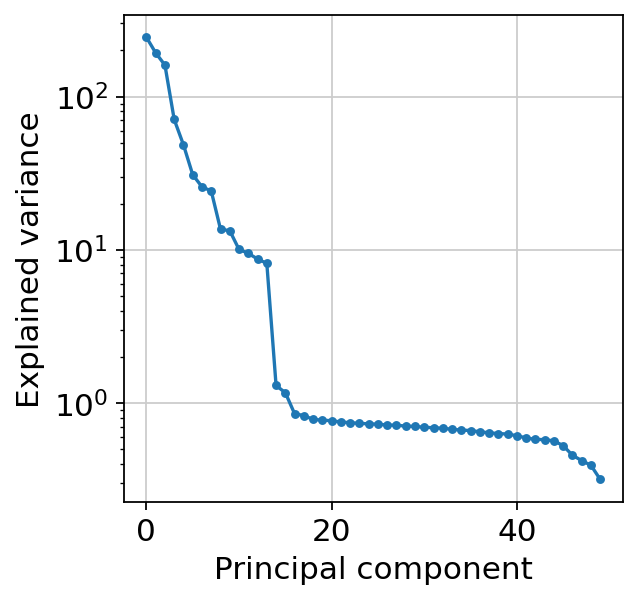

In [11]:
# small example plot of explained variance for principal components

plt.semilogy(pca_module.model.explained_variance_k, '.-')
plt.xlabel("Principal component")
plt.ylabel("Explained variance")
plt.show()

We now have a PCA module trained, but we have not computed and stored the PCs anywhere yet. For this 4M cell dataset we could, but we might have datasets where storing all the PCs in memory would be prohibitive.

In this demo, we will first use the PCA model to run geometric sketching, and then store a sketched AnnData that has the computed PCs.

## Geometric sketching

This is a method for smart downsampling of a large scRNA-seq dataset.

In [ ]:
# run geometric sketching

gsketch = cml.tl.geometric_sketch(
    cdata,
    target_n_cells=500000,
    embedding_module=pca_module,
    n_pcs=16,  # optional limit, can be None to use all computed PCs
    return_new_adata=True,
)

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name     | Type              | Params | Mode 
-------------------------------------------------------
0 | pipeline | CellariumPipeline | 2      | train
-------------------------------------------------------
1         Trainable params
1         Non-trainable params

/home/sfleming/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:106: Total length of `DataLoader` across ranks is zero. Please make sure this was your intention.
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:123: Your `IterableDataset` has `__len__` defined. In combination with multi-process data loading (when num_workers > 1), `__len__` could be inaccurate if each worker is not configured independently to avoid having duplicate data.


Epoch 0: 100%|██████████| 942/942 [11:33<00:00,  1.36it/s, current_cells=1.56e+5, proj_total_cells=1.56e+5, voxel_size=6.400, active_voxels=76415.0] 


/home/sfleming/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/home/sfleming/cellarium-ml/cellarium/ml/utilities/distributed.py:52: UserWarning: Distributed package is available but the default process group has not been initialized. Falling back to ``rank=0`` and ``num_replicas=1``.
  warnings.warn(
/home/sfleming/miniconda3/envs/cellarium/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [25]:
gsketch.keys()

dict_keys(['obs_names_in_sketch', 'adata', 'module'])

In [26]:
adata = gsketch["adata"]
adata

AnnData object with n_obs × n_vars = 155582 × 38094
    var: 'gene_id', 'gene_id_raw', 'hgnc_id', 'gene_type', 'gene_version', 'highly_variable'
    obsm: 'X_embedding'

## Further analysis in scanpy

Because the sketch is small and manageable in memory, we can use it with scanpy like normal.

In [27]:
sc.pp.neighbors(adata, use_rep="X_embedding", method="umap", metric="cosine")
sc.tl.umap(adata)

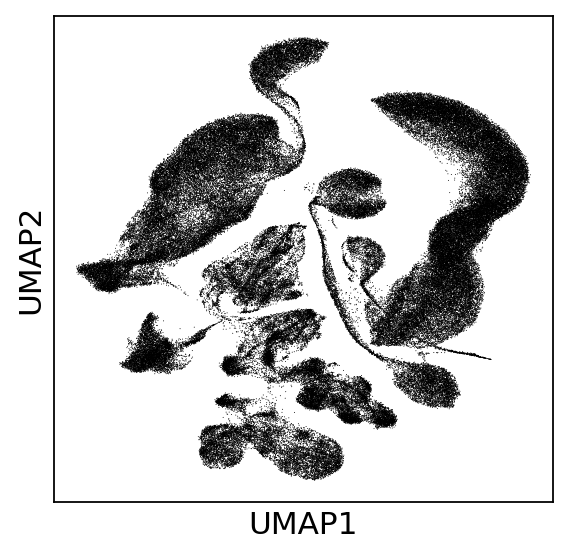

In [28]:
sc.pl.embedding(adata, basis="umap", na_color="k")

In [17]:
cdata

CellariumData(shape [3857513, 38094], obsm keys: [], hvg_set=True)

## Pull obs and color by metadata

In [ ]:
# property is lazy: first access actually pulls it from h5ad files; takes 10 mins

cdata.obs

Reading obs from GCS:   0%|          | 0/386 [00:00<?, ?file/s]

Merging obs parquet shards: 100%|██████████| 386/386 [01:18<00:00,  4.89file/s]


LazyObs(parquet_path=None, n_obs=3857513, columns=['age', 'assay', 'assay_ontology_term_id', 'biobank', 'brain_region_abbreviation', 'cell_barcode', 'cell_type', 'cell_type_ontology_term_id', 'cohort', 'data_freeze', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_external_id', 'donor_id', 'experiment', 'expression_doublet', 'extraction', 'frac_contamination', 'hbcac_status', 'imputed_sex', 'mmc_class_name', 'mmc_cluster_name', 'mmc_group_name', 'mmc_neighborhood_name', 'mmc_subclass_name', 'n_counts', 'neuropath_diagnosis', 'num_genes', 'num_genic_reads', 'num_retained_transcripts', 'num_transcripts', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'pct_utr', 'prefix', 'race', 'scpred_class', 'scpred_sub_class', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sequencing_assay', 'sex', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'village'])

In [29]:
# cached to local disk: fast

cdata.obs

LazyObs(parquet_path='/tmp/cellarium_obs_parquet_55sn8k67/obs.parquet', n_obs=3857513, columns=['age', 'assay', 'assay_ontology_term_id', 'biobank', 'brain_region_abbreviation', 'cell_barcode', 'cell_type', 'cell_type_ontology_term_id', 'cohort', 'data_freeze', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_external_id', 'donor_id', 'experiment', 'expression_doublet', 'extraction', 'frac_contamination', 'hbcac_status', 'imputed_sex', 'mmc_class_name', 'mmc_cluster_name', 'mmc_group_name', 'mmc_neighborhood_name', 'mmc_subclass_name', 'n_counts', 'neuropath_diagnosis', 'num_genes', 'num_genic_reads', 'num_retained_transcripts', 'num_transcripts', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'pct_utr', 'prefix', 'race', 'scpred_class', 'scpred_sub_class', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sequencing_assay', 'sex', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'village']

In [30]:
cdata.obs.columns

['age',
 'assay',
 'assay_ontology_term_id',
 'biobank',
 'brain_region_abbreviation',
 'cell_barcode',
 'cell_type',
 'cell_type_ontology_term_id',
 'cohort',
 'data_freeze',
 'development_stage',
 'development_stage_ontology_term_id',
 'disease',
 'disease_ontology_term_id',
 'donor_external_id',
 'donor_id',
 'experiment',
 'expression_doublet',
 'extraction',
 'frac_contamination',
 'hbcac_status',
 'imputed_sex',
 'mmc_class_name',
 'mmc_cluster_name',
 'mmc_group_name',
 'mmc_neighborhood_name',
 'mmc_subclass_name',
 'n_counts',
 'neuropath_diagnosis',
 'num_genes',
 'num_genic_reads',
 'num_retained_transcripts',
 'num_transcripts',
 'pct_intergenic',
 'pct_intronic',
 'pct_mt',
 'pct_utr',
 'prefix',
 'race',
 'scpred_class',
 'scpred_sub_class',
 'self_reported_ethnicity',
 'self_reported_ethnicity_ontology_term_id',
 'sequencing_assay',
 'sex',
 'suspension_type',
 'tissue',
 'tissue_ontology_term_id',
 'tissue_type',
 'village']

In [31]:
# add metadata from cdata to adata

adata.obs = cdata.obs.loc[
    adata.obs_names, 
    [
        'cell_type', 'village', 'brain_region_abbreviation', 'sex',
        'scpred_class', 'scpred_sub_class', 'donor_id', 'biobank',
    ]
]

In [32]:
adata.obs

,cell_type,village,brain_region_abbreviation,sex,scpred_class,scpred_sub_class,donor_id,biobank
soma_joinid,,,,,,,,
1308892,microglial cell,v20,Pu,female,microglia,NA,MS986638,Mt.Sinai
3610048,interneuron,v8,CaH,female,interneuron,NA,PT13641,Pittsburgh
3169229,microglial cell,v7,DFC,male,microglia,NA,PT13770,Pittsburgh
236573,astrocyte,v12,CaH,female,astrocyte,NA,MS652464,Mt.Sinai
2691955,L2/3 intratelencephalic projecting glutamaterg...,v51,DFC,male,glutamatergic,L23IT,PT13965,Pittsburgh
...,...,...,...,...,...,...,...,...
3768222,microglial cell,v94,NAC,male,microglia,NA,MD6570,Maryland
428964,astrocyte,v12,CaH,male,astrocyte,NA,MD6666,Maryland
2577714,microglial cell,v48,NACc,male,microglia,NA,MLS09438,Harvard


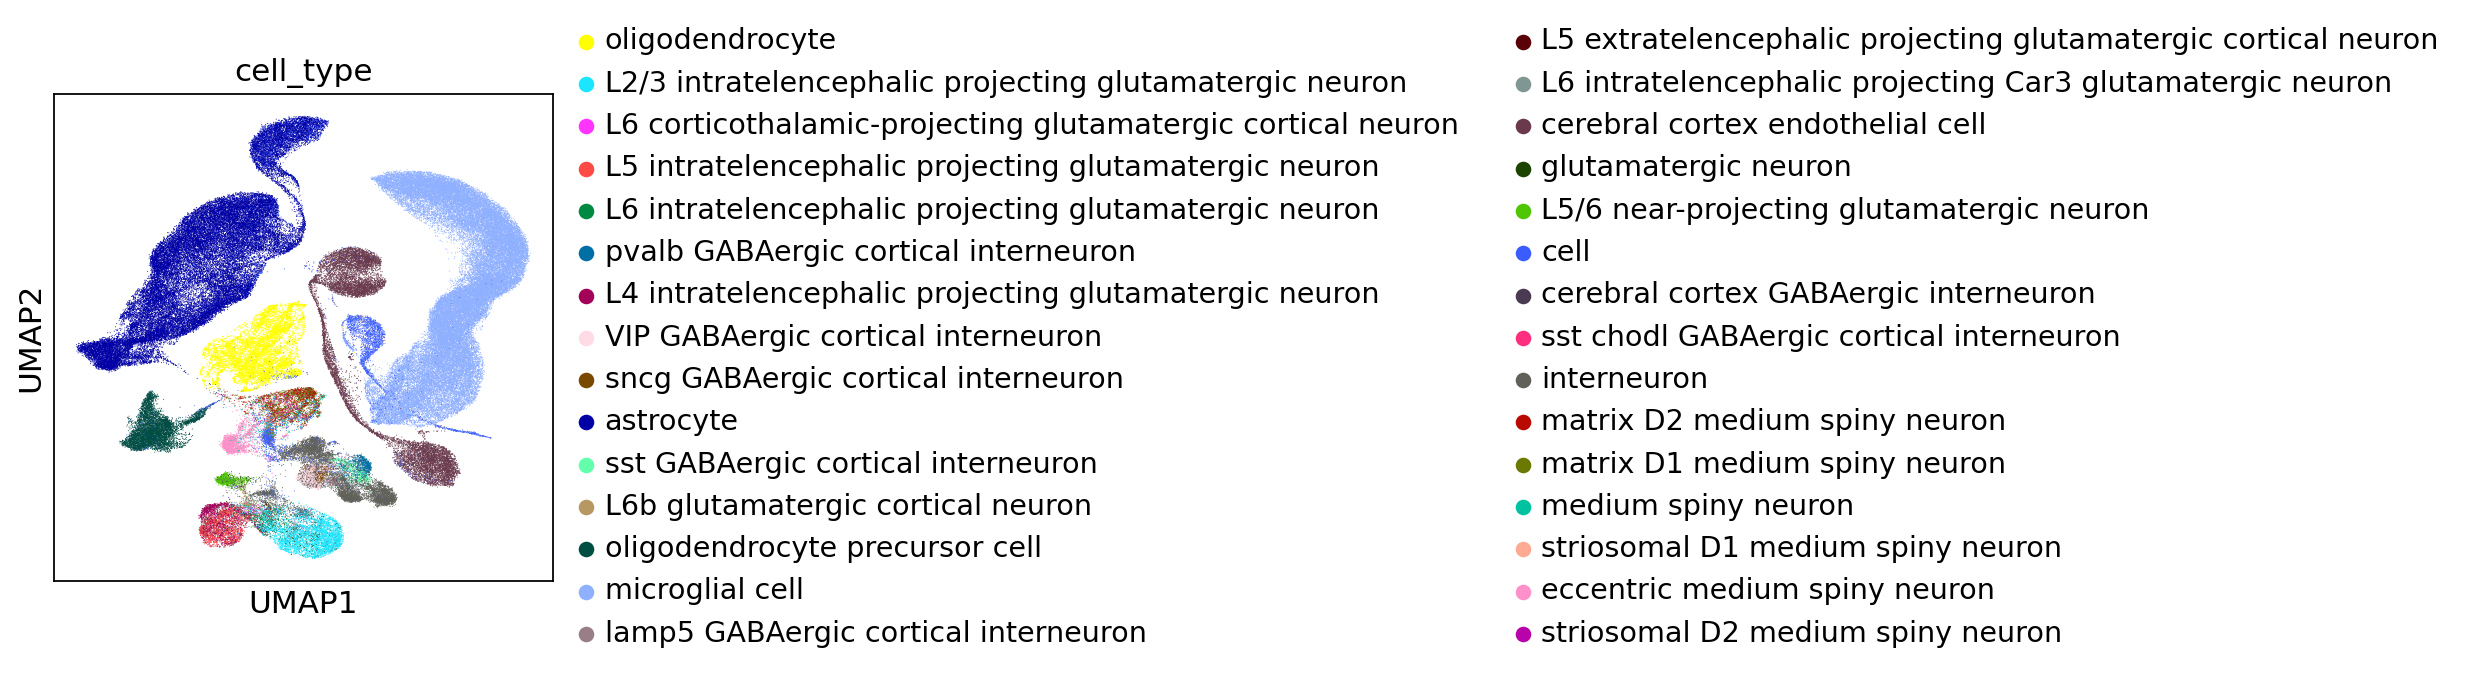

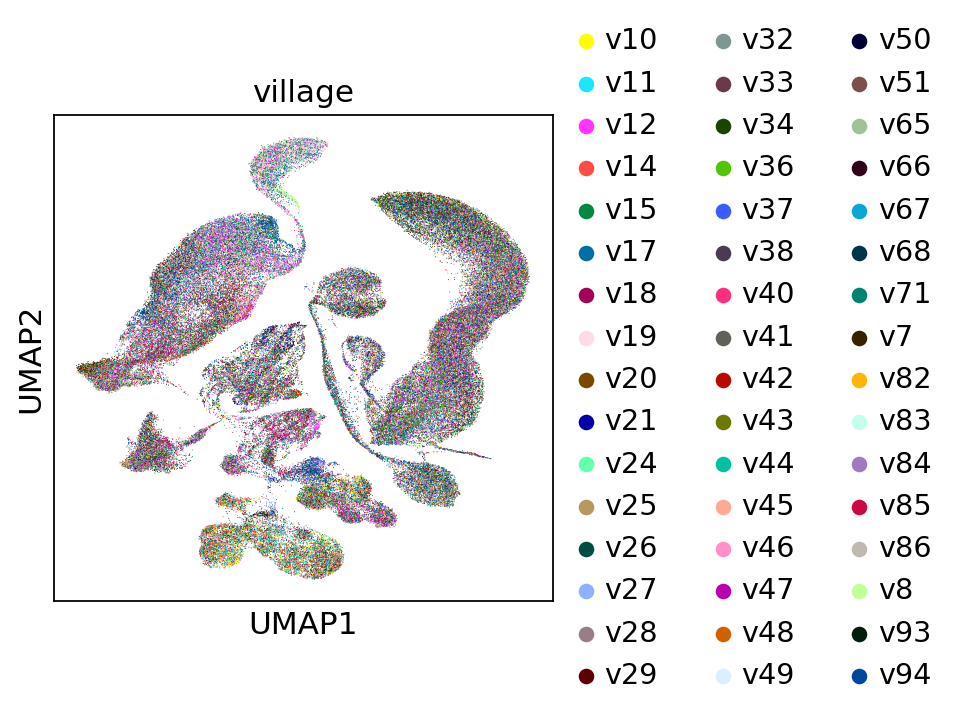

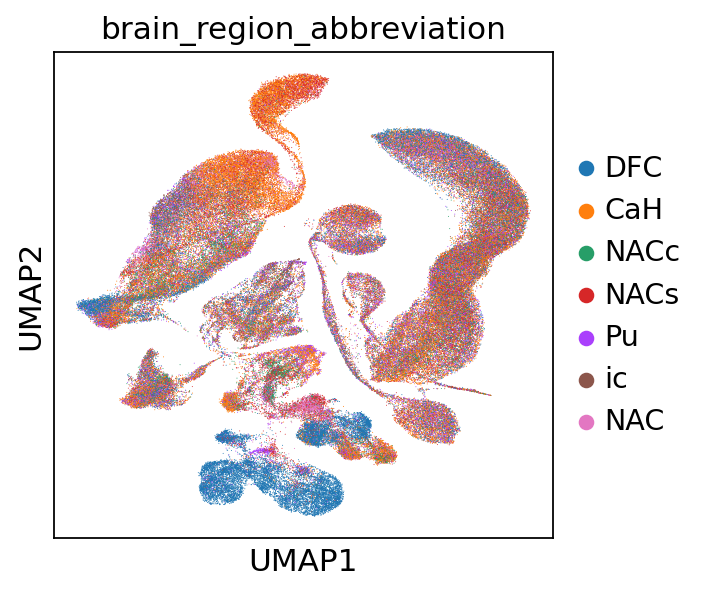

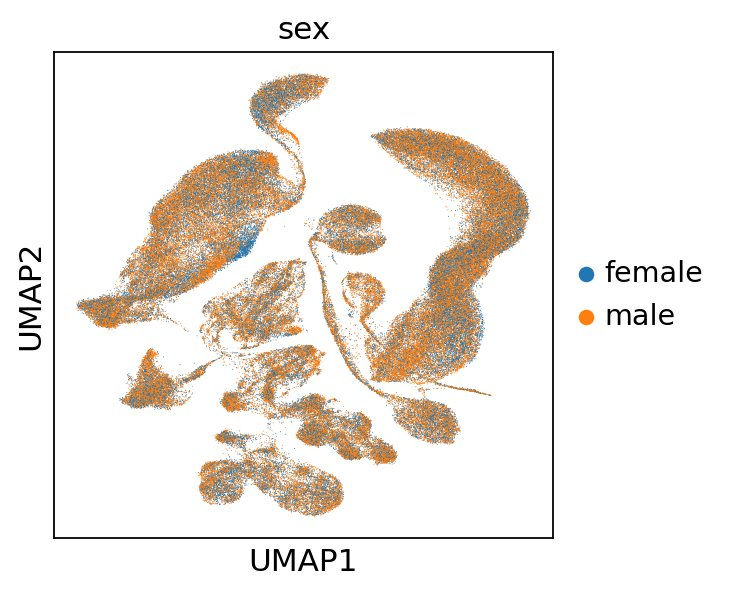

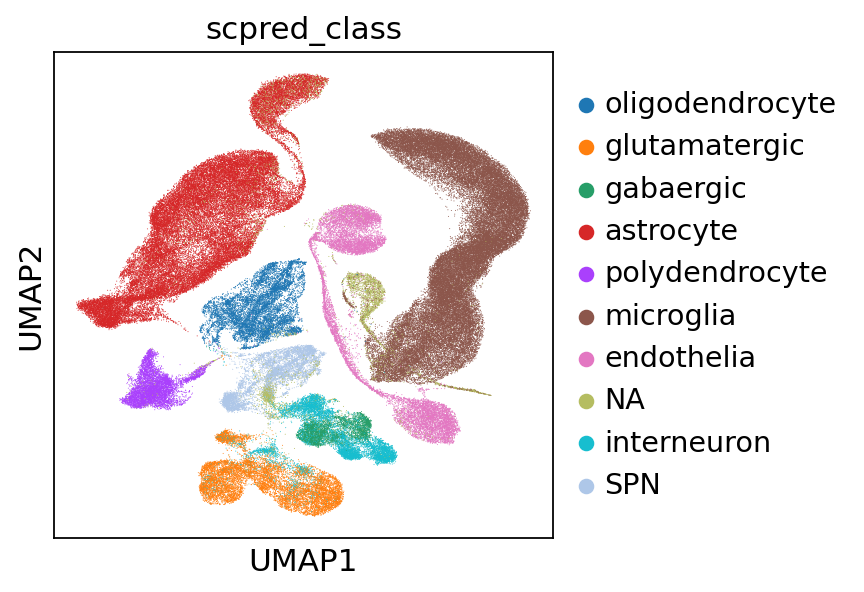

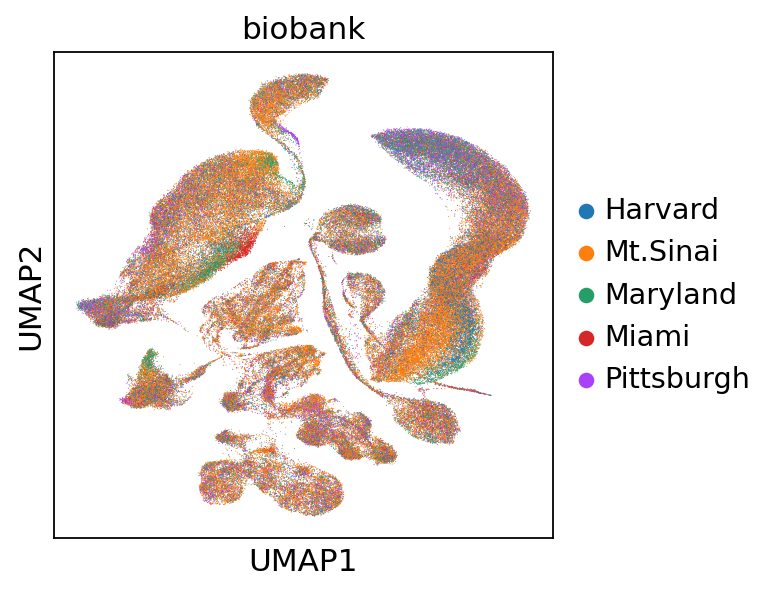

In [33]:
# plot UMAP with a few different values for coloring

for col in ["cell_type", "village", "brain_region_abbreviation", "sex", "scpred_class", "biobank"]:
    sc.pl.embedding(adata, basis="umap", color=col, ncols=1)